In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from deep_isochron.model.invertible import (
    AffineCoupling,
    InvertibleLinear,
    MonotonicRQCoupling,
    SequentialINN,
)
from deep_isochron.model.latent_dynamics import (
    HopfLatentDynamics,
    HopfNormalForm,
)
from deep_isochron.systems.fitzhugh_nagumo import FitzhughNagumo
from deep_isochron.training import (
    RandomSampleBatching,
    SegmentLoader,
    TimeSeriesDataset,
    VanillaTrainer,
)
from jaxtyping import Array, Float


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[1])


In [2]:
dyn = HopfLatentDynamics(dim=10, num_eig_comp=0, key=jax.random.key(0))
dyn.linear.eigenvalues

(Array([], shape=(0, 2), dtype=float64),
 Array([-1.29138111, -0.8631045 , -1.07735964, -1.30697225, -0.84435225,
        -0.88660562, -0.98987331, -0.86740485], dtype=float64))

In [3]:
ts = jnp.arange(0, 20.0, 0.01)
y0 = jax.random.uniform(jax.random.key(0), shape=(dyn.dim,))

In [4]:
out = dyn(ts, y0)

In [5]:
out.shape

(2000, 10)

In [6]:
from deep_isochron.model.invertible import AbstractInvertibleTransform
from deep_isochron.model.latent_dynamics import AbstractLatentDynamics


class LatentDynamicsConverter(eqx.Module):
    latent_dynamics: AbstractLatentDynamics
    bijection: AbstractInvertibleTransform

    def __init__(
        self,
        latent_dynamics: AbstractLatentDynamics,
        bijection: AbstractInvertibleTransform,
    ):
        self.latent_dynamics = latent_dynamics
        self.bijection = bijection

    @property
    def dim(self) -> int:
        return self.latent_dynamics.dim

    def __call__(
        self,
        ts: Float[Array, " time"],
        x0: Float[Array, " obs_dim"],
        return_latent_trajectory: bool = True,
    ) -> tuple[Float[Array, "time obs_dim"], Float[Array, "time latent_dim"] | None]:
        y0: Float[Array, " latent_dim"] = self.bijection(x0)
        yt: Float[Array, "time latent_dim"] = self.latent_dynamics(ts, y0)
        xt: Float[Array, "time obs_dim"] = eqx.filter_vmap(self.bijection.inverse)(yt)

        if return_latent_trajectory:
            return xt, yt
        else:
            return xt, None


In [7]:
autoencoder = LatentDynamicsConverter(
    latent_dynamics=HopfNormalForm(init_period=10),
    bijection=SequentialINN(
        [
            InvertibleLinear(dim=2, key=jax.random.key(0)),
            MonotonicRQCoupling(
                dim=2,
                width_hidden=32,
                num_knots=10,
                xy_range=(-4, 4),
                key=jax.random.key(1),
            ),
            InvertibleLinear(dim=2, key=jax.random.key(2)),
            MonotonicRQCoupling(
                dim=2,
                width_hidden=32,
                num_knots=10,
                xy_range=(-4, 4),
                key=jax.random.key(3),
            ),
            InvertibleLinear(dim=2, key=jax.random.key(4)),
            MonotonicRQCoupling(
                dim=2,
                width_hidden=32,
                num_knots=10,
                xy_range=(-4, 4),
                key=jax.random.key(5),
            ),
        ]
    ),
)

In [ ]:
autoencoder = LatentDynamicsConverter(
    latent_dynamics=HopfNormalForm(init_period=10),
    bijection=SequentialINN(
        [
            InvertibleLinear(dim=2, key=jax.random.key(0)),
            AffineCoupling(
                dim=2,
                width_hidden=32,
                affine_clamping=1.0,
                key=jax.random.key(1),
            ),
            InvertibleLinear(dim=2, key=jax.random.key(2)),
            AffineCoupling(
                dim=2,
                width_hidden=32,
                affine_clamping=1.0,
                key=jax.random.key(3),
            ),
            InvertibleLinear(dim=2, key=jax.random.key(4)),
            AffineCoupling(
                dim=2,
                width_hidden=32,
                affine_clamping=1.0,
                key=jax.random.key(5),
            ),
        ]
    ),
)

## Generate data for Fitahugh-Nagumo

In [16]:
ode = FitzhughNagumo()

u0 = jnp.asarray([1.0, 0.0])
t = jnp.linspace(0, 100, 1000)
sol = dfx.diffeqsolve(
    dfx.ODETerm(ode.rhs),
    dfx.Tsit5(),
    t[0],
    t[-1],
    None,
    u0,
    stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-6),
    saveat=dfx.SaveAt(ts=t),
)

In [17]:
n_trajs = 1000
t = jnp.arange(0, 50 + 0.01, 0.01)


def solve_single(
    ode,
    ts: Float[Array, " time"],
    u0: Float[Array, " dim"],
    rtol: float = 1e-8,
    atol: float = 1e-10,
    solver: dfx.AbstractSolver = dfx.Tsit5(),
):
    sol: dfx.Solution = dfx.diffeqsolve(
        dfx.ODETerm(ode.rhs),
        solver,
        ts[0],
        ts[-1],
        None,
        u0,
        stepsize_controller=dfx.PIDController(rtol=rtol, atol=atol),
        saveat=dfx.SaveAt(ts=t),
    )
    return sol.ys


u0_train = jax.random.uniform(
    jax.random.key(0), (n_trajs, ode.dim), minval=-3, maxval=3
)
u_train = eqx.filter_vmap(solve_single, in_axes=(None, None, 0))(ode, t, u0_train)
print(u_train.shape)

(1000, 5001, 2)


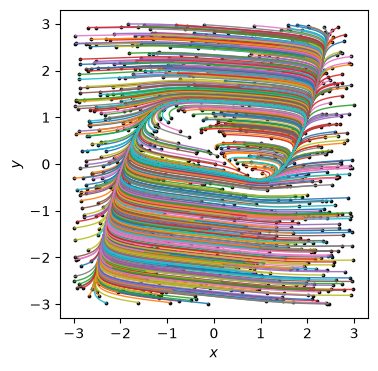

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i in range(0, len(u_train)):
    ax.plot(*u_train[i].T, alpha=0.9, linewidth=1.0)
ax.scatter(*u_train[:, 0].T, s=3, color="black", alpha=0.9)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")

In [19]:
u_pred, y_pred = eqx.filter_vmap(autoencoder, in_axes=(None, 0))(t, u_train[:, 0])
u_pred.shape

(1000, 5001, 2)

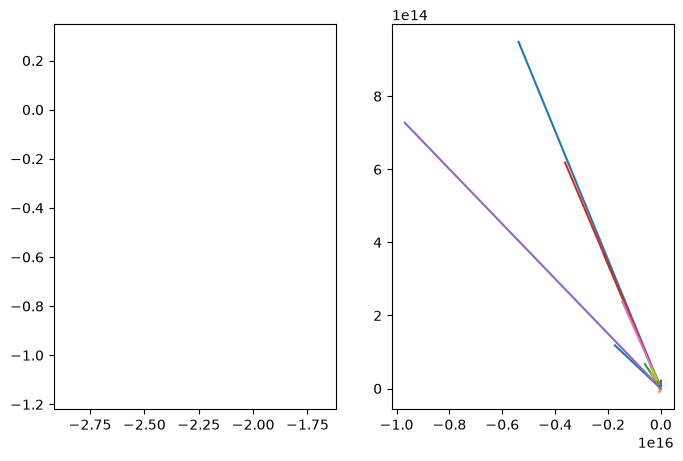

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
for i in range(0, len(u_pred), 5):
    axes[0].plot(*u_pred[i].T)
    axes[1].plot(*y_pred[i].T)

In [14]:
u_train_ae = eqx.filter_vmap(
    lambda x: autoencoder.bijection.inverse(autoencoder.bijection(x))
)(u_train[:, 0])
jnp.max(jnp.abs(u_train[:, 0] - u_train_ae))

Array(nan, dtype=float64)

In [14]:
def loss_inn(model: LatentDynamicsConverter, batch, args=None):
    t_batch: Float[Array, "batch time"]
    x_batch: Float[Array, "batch time dim"]
    t_batch, x_batch = batch
    x_pred, y_pred = eqx.filter_vmap(model)(t_batch, x_batch[:, 0])
    # y_pred: Float[Array, "batch time latent_dim"] = eqx.filter_vmap(
    #     lambda t, x0: model.latent_dynamics(t, model.encoder(x0))
    # )(t_batch, x_batch[:, 0])
    # # x_pred: Float[Array, "batch time dim"] = eqx.filter_vmap(model)(
    # #     t_batch, x_batch[:, 0]
    # # )
    # x_pred = jax.vmap(jax.vmap(model.decoder))(y_pred)
    mse = jnp.mean((x_batch - x_pred) ** 2)

    y_batch = jax.vmap(jax.vmap(model.bijection))(x_batch)
    mse_latent = jnp.mean((y_batch - y_pred) ** 2)

    # x_ae = jax.vmap(jax.vmap(model.decoder))(y_batch)
    # y_ae = jax.vmap(jax.vmap(model.encoder))(x_ae)
    # loss_identity = jnp.mean((x_batch - x_ae) ** 2)
    # loss_identity_latent = jnp.mean((y_batch - y_ae) ** 2)

    # Weighting the latent space mse by 0
    return mse + mse_latent, {
        "mse": mse,
        # "identity_loss": loss_identity,
        # "identity_latent_loss": loss_identity_latent,
        "mse_latent": mse_latent,
    }

In [15]:
dataset = TimeSeriesDataset(t, u_train)
loader = SegmentLoader(
    dataset,
    segment_length=100,
    batch_strategy=RandomSampleBatching(batch_size=2048),
)
loader_state = loader.init()
batch, loader_state = loader.load_batch(loader_state)

In [ ]:
batch_pred = eqx.filter_vmap(autoencoder)(batch[0], batch[1][:, 0])[0]

(-3.5, 3.5)

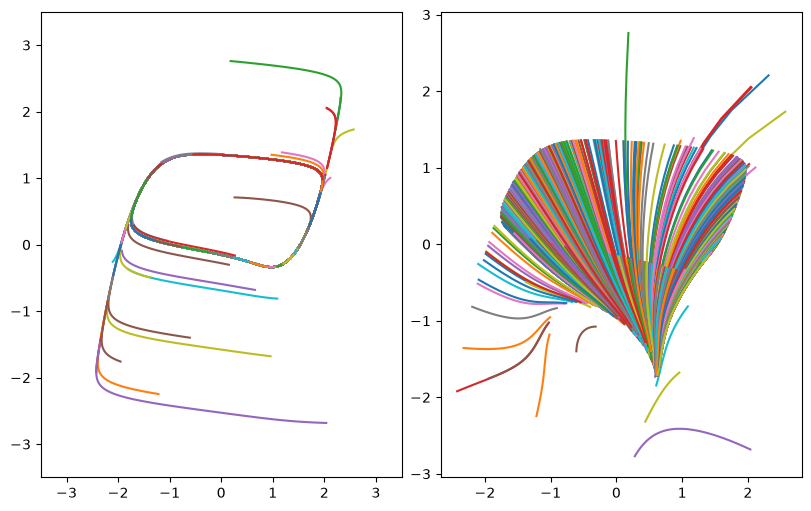

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)
for i in range(0, len(batch[1]), 2):
    axes[0].plot(*batch[1][i].T)
    axes[1].plot(*batch_pred[i].T)
axes[0].set_xlim((-3.5, 3.5))
axes[0].set_ylim((-3.5, 3.5))

In [26]:
trainer = VanillaTrainer(
    optax.adamw(learning_rate=1e-3),
    max_epochs=2000,
    wandb_entity="jhko725",
    wandb_project="isochron",
)

In [27]:
model_trained, loss_history = trainer.train(
    autoencoder, loss_inn, train_loader=loader, config={"model": []}
)

step=0, loss=Array(2.43393307, dtype=float64)
step=1, loss=Array(2.3686869, dtype=float64)
step=2, loss=Array(2.25645145, dtype=float64)
step=3, loss=Array(2.21593966, dtype=float64)
step=4, loss=Array(2.1113059, dtype=float64)
step=5, loss=Array(2.10549751, dtype=float64)
step=6, loss=Array(1.99994913, dtype=float64)
step=7, loss=Array(1.94367416, dtype=float64)
step=8, loss=Array(1.91096344, dtype=float64)
step=9, loss=Array(1.79270348, dtype=float64)
step=10, loss=Array(1.78372012, dtype=float64)
step=11, loss=Array(1.76124563, dtype=float64)
step=12, loss=Array(1.70299192, dtype=float64)
step=13, loss=Array(1.59929762, dtype=float64)
step=14, loss=Array(1.51853346, dtype=float64)
step=15, loss=Array(1.54807819, dtype=float64)
step=16, loss=Array(1.48058529, dtype=float64)
step=17, loss=Array(1.43394209, dtype=float64)
step=18, loss=Array(1.41365517, dtype=float64)
step=19, loss=Array(1.33920747, dtype=float64)
step=20, loss=Array(1.3299374, dtype=float64)
step=21, loss=Array(1.2759

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


loss_train,██▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse_latent_train,█▅▅▄▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse_train,█▅▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_train,0.01531
mse_latent_train,0.00529
mse_train,0.01002


In [28]:
t_subset, u_train_subset = dataset.t[::10, ::5], dataset.u[::10, ::5]  # batch
u_pred_subset, w_pred_subset = eqx.filter_vmap(model_trained)(
    t_subset, u_train_subset[:, 0]
)

t_longer = jnp.arange(
    t_subset[0, 0], 4 * t_subset[0, -1], t_subset[0, 1] - t_subset[0, 0]
)
u_longer = eqx.filter_vmap(model_trained, in_axes=(None, 0))(
    t_longer, u_train_subset[:, 0]
)[0]

In [29]:
model_trained.latent_dynamics.period

Array(10.33918109, dtype=float64)

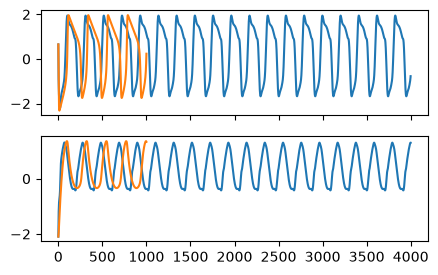

In [32]:
traj_idx = 50
fig, axes = plt.subplots(2, 1, figsize=(5, 3), sharex=True)
for i, ax in enumerate(axes):
    # ax.plot(u_pred_subset[traj_idx, :, i], "--")
    ax.plot(u_longer[traj_idx, :, i])
    ax.plot(u_train_subset[traj_idx, :, i])

# ax.set_xlim((1500,2000))

Text(0.5, 1.0, 'Model latent space')

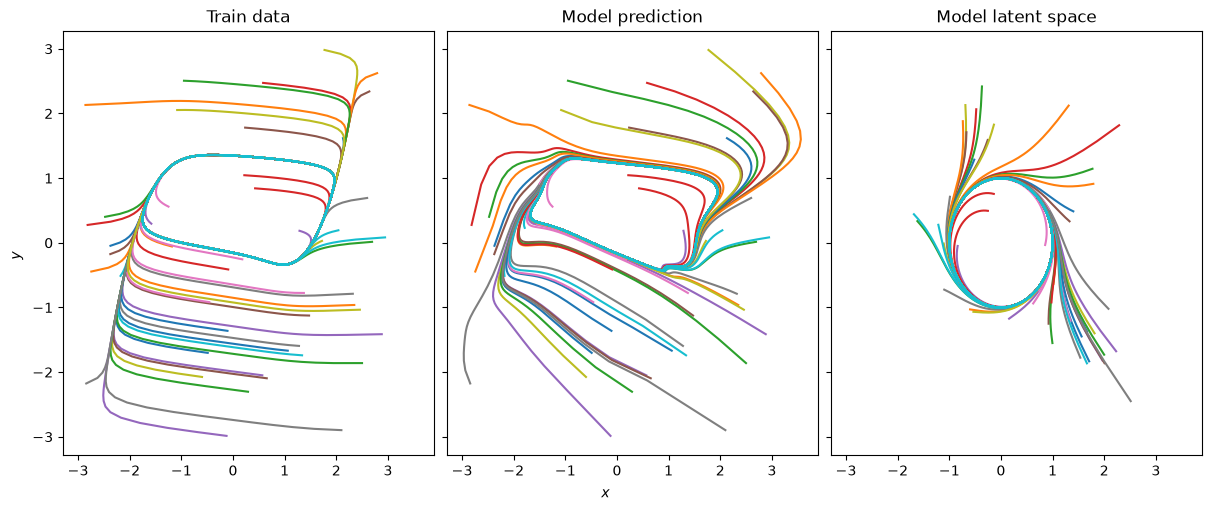

In [33]:
fig, axes = plt.subplots(
    1, 3, figsize=(12, 5), constrained_layout=True, sharex=True, sharey=True
)
for i in range(0, len(u_train_subset), 2):
    axes[0].plot(*u_train_subset[i].T)
    axes[1].plot(*u_pred_subset[i].T)
    axes[2].plot(*w_pred_subset[i].T)
# axes[0].set_xlim((-3.5, 3.5))
# axes[0].set_ylim((-3.5, 3.5))
fig.supxlabel("$x$", fontsize="medium")
fig.supylabel("$y$", fontsize="medium")
axes[0].set_title("Train data")
axes[1].set_title("Model prediction")
axes[2].set_title("Model latent space")